# Task 1: Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis of Reuters headlines dataset. We will analyze:
1. Basic dataset properties
2. Number of unique articles
3. Trends over time
4. Patterns in headlines and descriptions
5. Data quality and preprocessing

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re
from textblob import TextBlob
import spacy
from wordcloud import WordCloud

# Set plot style
sns.set_theme()
sns.set_palette('husl')

In [2]:
# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to /home/uwais/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/uwais/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/uwais/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /home/uwais/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /home/uwais/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

## 1. Data Loading and Basic Properties

In [3]:
# Read the dataset
df = pd.read_csv('data/reuters_headlines.csv')

# Display basic information
print("=== Dataset Info ===")
print(df.info())

print("\n=== First few rows ===")
display(df.head())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32770 entries, 0 to 32769
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Headlines    32770 non-null  object
 1   Time         32770 non-null  object
 2   Description  32770 non-null  object
dtypes: object(3)
memory usage: 768.2+ KB
None

=== First few rows ===


,Headlines,Time,Description
0,TikTok considers London and other locations fo...,Jul 18 2020,TikTok has been in discussions with the UK gov...
1,Disney cuts ad spending on Facebook amid growi...,Jul 18 2020,Walt Disney has become the latest company to ...
2,Trail of missing Wirecard executive leads to B...,Jul 18 2020,Former Wirecard chief operating officer Jan M...
3,Twitter says attackers downloaded data from up...,Jul 18 2020,Twitter Inc said on Saturday that hackers were...
4,U.S. Republicans seek liability protections as...,Jul 17 2020,A battle in the U.S. Congress over a new coron...


## 2. Data Quality Check and Preprocessing

In [4]:
# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Convert Time to datetime
df['Time'] = pd.to_datetime(df['Time'], format='%b %d %Y')

# Basic text cleaning function
def clean_text(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower()

def get_word_stats(text_series):
    # Combine all text
    all_text = ' '.join(text_series.apply(clean_text))
    
    # Tokenize words
    words = word_tokenize(all_text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words and len(word) > 2]
    
    return Counter(words)

=== Missing Values ===
Headlines      0
Time           0
Description    0
dtype: int64


## 3. Basic Dataset Statistics

In [5]:
print("=== Basic Dataset Statistics ===")
print(f"Total number of articles: {len(df)}")
print(f"Date range: from {df['Time'].min()} to {df['Time'].max()}")

print("\n=== Uniqueness Analysis ===")
print(f"Number of unique headlines: {df['Headlines'].nunique()}")
print(f"Number of unique descriptions: {df['Description'].nunique()}")

=== Basic Dataset Statistics ===
Total number of articles: 32770
Date range: from 2018-03-20 00:00:00 to 2020-07-18 00:00:00

=== Uniqueness Analysis ===
Number of unique headlines: 32575
Number of unique descriptions: 32574


## 4. Text Pattern Analysis

In [6]:
# Analyze headlines
headline_word_freq = get_word_stats(df['Headlines'])
print("Most common words in headlines:")
display(pd.DataFrame(headline_word_freq.most_common(10), columns=['Word', 'Count']))

# Analyze descriptions
desc_word_freq = get_word_stats(df['Description'])
print("\nMost common words in descriptions:")
display(pd.DataFrame(desc_word_freq.most_common(10), columns=['Word', 'Count']))

Most common words in headlines:


,Word,Count
0,says,2942
1,china,2293
2,trade,2286
3,billion,1743
4,new,1621
5,deal,1602
6,ceo,1468
7,coronavirus,1412
8,oil,1363
9,sources,1302



Most common words in descriptions:


,Word,Count
0,said,13719
1,inc,4980
2,thursday,4394
3,wednesday,4360
4,tuesday,4351
5,trade,4025
6,billion,3921
7,friday,3779
8,monday,3745
9,new,3609


## 5. Visualizations

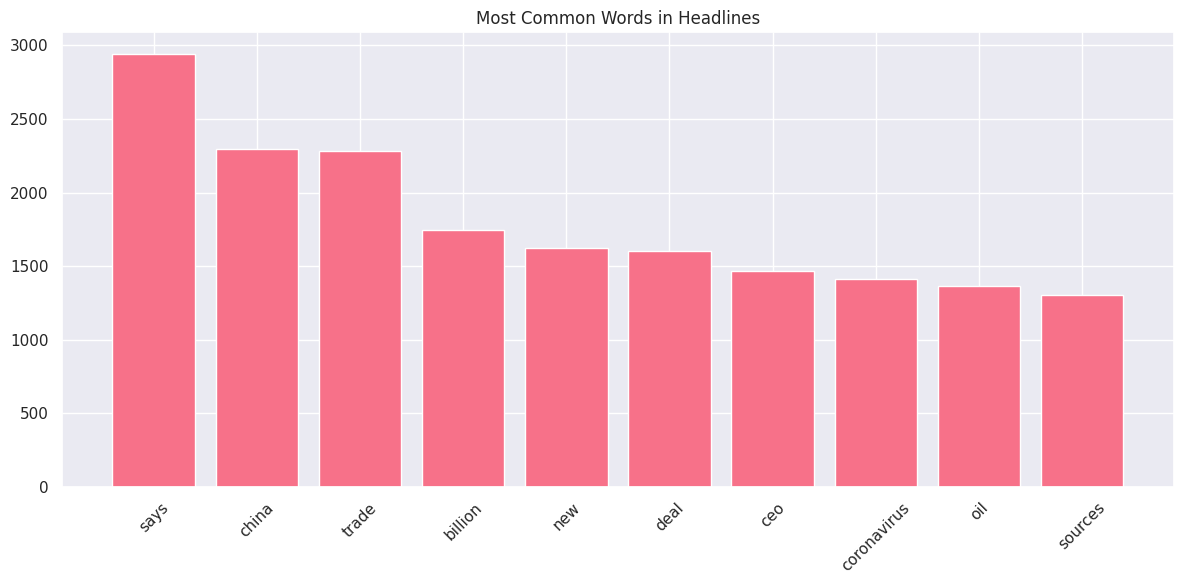

In [7]:
# Plot top 10 words in headlines
plt.figure(figsize=(12, 6))
words, counts = zip(*headline_word_freq.most_common(10))
plt.bar(words, counts)
plt.title('Most Common Words in Headlines')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

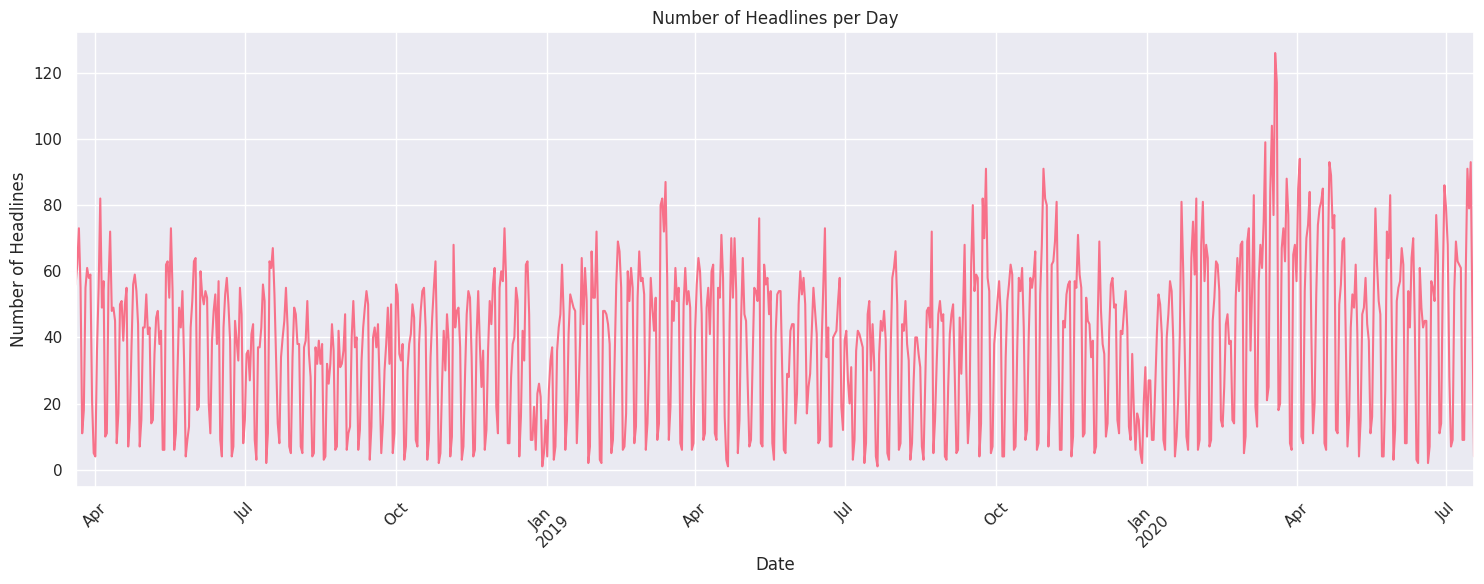

In [8]:
# Headlines per day
plt.figure(figsize=(15, 6))
df['Time'].value_counts().sort_index().plot(kind='line')
plt.title('Number of Headlines per Day')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

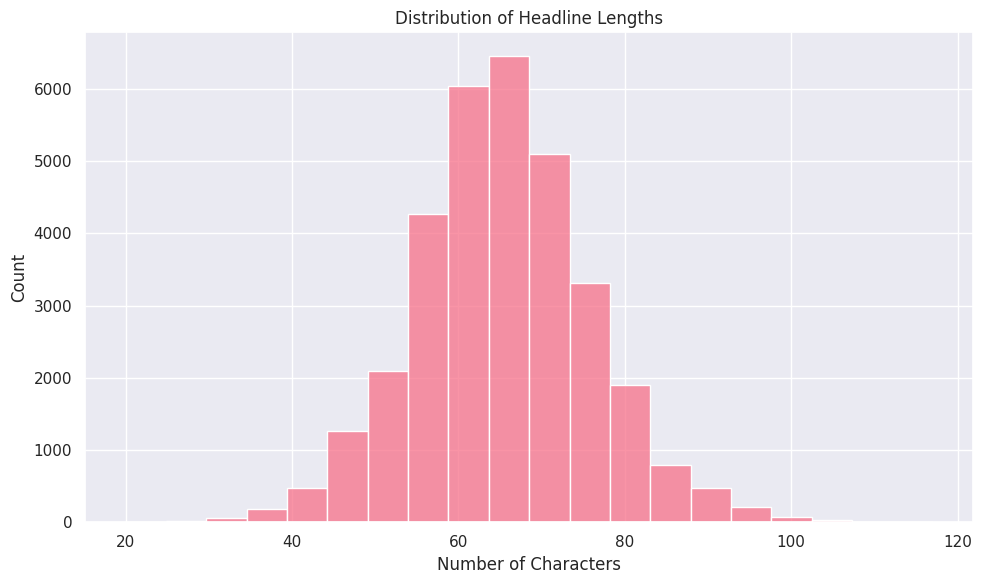


=== Headline Length Statistics ===
count    32770.000000
mean        65.290571
std         10.675765
min         20.000000
25%         58.000000
50%         65.000000
75%         72.000000
max        117.000000
Name: headline_length, dtype: float64


In [9]:
# Headline length analysis
df['headline_length'] = df['Headlines'].str.len()
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='headline_length', bins=20)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.tight_layout()
plt.show()

print("\n=== Headline Length Statistics ===")
print(df['headline_length'].describe())

## 6. Sentiment Analysis

In [10]:
# Add sentiment analysis
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Calculate sentiment scores
df['headline_sentiment'] = df['Headlines'].apply(get_sentiment)
df['description_sentiment'] = df['Description'].apply(get_sentiment)

print("=== Sentiment Analysis ===")
print("\nHeadline Sentiment Statistics:")
print(df['headline_sentiment'].describe())
print("\nDescription Sentiment Statistics:")
print(df['description_sentiment'].describe())

=== Sentiment Analysis ===

Headline Sentiment Statistics:
count    32770.000000
mean         0.027163
std          0.177320
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: headline_sentiment, dtype: float64

Description Sentiment Statistics:
count    32770.000000
mean         0.055496
std          0.169205
min         -1.000000
25%          0.000000
50%          0.011111
75%          0.136364
max          1.000000
Name: description_sentiment, dtype: float64


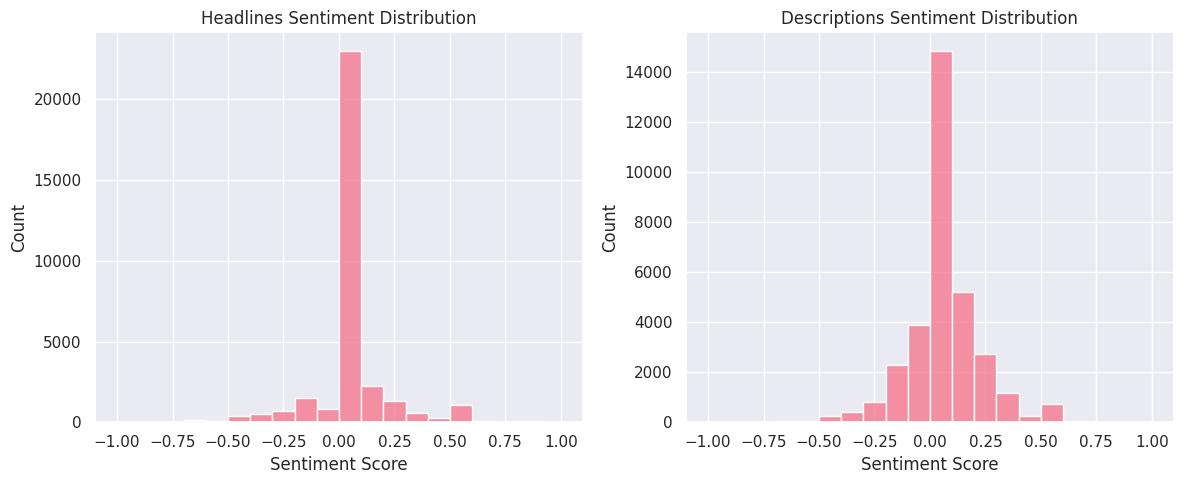

In [11]:
# Visualize sentiment distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['headline_sentiment'], bins=20)
plt.title('Headlines Sentiment Distribution')
plt.xlabel('Sentiment Score')

plt.subplot(1, 2, 2)
sns.histplot(df['description_sentiment'], bins=20)
plt.title('Descriptions Sentiment Distribution')
plt.xlabel('Sentiment Score')
plt.tight_layout()
plt.show()

## 7. Named Entity Recognition

In [12]:
# Load spaCy model
nlp = spacy.load('en_core_web_sm')

def extract_organizations(text):
    doc = nlp(text)
    return [ent.text for ent in doc.ents if ent.label_ == 'ORG']

# Extract organizations from headlines
df['organizations'] = df['Headlines'].apply(extract_organizations)
all_orgs = [org for orgs in df['organizations'] for org in orgs]
org_freq = Counter(all_orgs)

print("=== Top Mentioned Organizations ===")
display(pd.DataFrame(org_freq.most_common(10), columns=['Organization', 'Count']))

=== Top Mentioned Organizations ===


,Organization,Count
0,Boeing,935
1,Fed,834
2,Trump,783
3,EU,718
4,MAX,583
5,Huawei,559
6,Amazon,486
7,Apple,483
8,Airbus,418
9,Nissan,354


## 8. Word Cloud Visualization

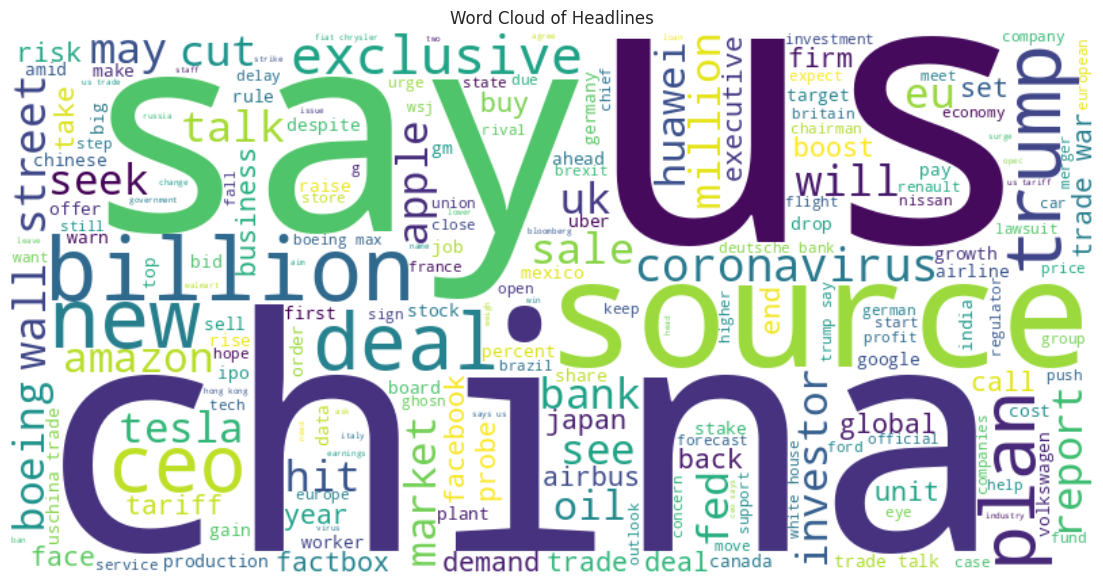

In [13]:
# Generate word cloud
plt.figure(figsize=(12, 6))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['Headlines'].apply(clean_text)))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Headlines')
plt.tight_layout()
plt.show()